# Exercise 3 - BERT
_By Abigail Hayes. Based on content by Indira Sen and [AI for Humanists](https://aiforhumanists.com/tutorials/)._

In this exercise you will work with [HuggingFace](https://huggingface.co/) and specifically [BERT](https://huggingface.co/docs/transformers/en/model_doc/bert) models. We will look at finetuning models and using pretrained versions. 

There will then be the opportunity to try further variants yourself.

## Setup

First we will set up our environment and prepare a dataset.

### Environment

If these Python packages are not yet available in your environment, then you should install them.
- numpy - for working with data
- pandas - for data analysis
- sklearn - for machine learning
- torch - for deep learning (instructions [here](https://pytorch.org/))
- transformers - for working with HuggingFace
- accelerate - simplify distributed training
- datasets - for handling datasets

In [ ]:
%pip install numpy pandas scikit-learn torch transformers accelerate datasets

In [1]:
from collections import defaultdict
import pandas as pd

### Download data

We will use the same dataset as last week.

In [2]:
datapath = 'https://raw.githubusercontent.com/leelaylay/TweetSemEval/master/dataset/train/twitter-2013train-A.txt'
data = pd.read_csv(datapath, sep = '\t', names = ['id', 'sentiment', 'text'])
data

,id,sentiment,text
0,264183816548130816,positive,Gas by my house hit $3.39!!!! I\u2019m going t...
1,263405084770172928,negative,Theo Walcott is still shit\u002c watch Rafa an...
2,262163168678248449,negative,its not that I\u2019m a GSP fan\u002c i just h...
3,264249301910310912,negative,Iranian general says Israel\u2019s Iron Dome c...
4,262682041215234048,neutral,Tehran\u002c Mon Amour: Obama Tried to Establi...
...,...,...,...
9679,103158179306807296,positive,RT @MNFootNg It's monday and Monday Night Foot...
9680,103157324096618497,positive,All I know is the road for that Lomardi start ...
9681,100259220338905089,neutral,"All Blue and White fam, we r meeting at Golden..."
9682,104230318525001729,positive,@DariusButler28 Have a great game agaist Tam...


## DistilBERT

We will work with the [DistilBERT](https://huggingface.co/docs/transformers/en/model_doc/distilbert) model. We can download this from HuggingFace.

In [3]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments

 We also set some basic configuration settings.

In [4]:
model_name = 'distilbert-base-uncased'
device_name = 'cuda'

# This is the maximum number of tokens in any document; the rest will be truncated.
max_length = 512

# This is the name of the directory where we'll save our model. You can name it whatever you want.
cached_model_directory_name = 'output_hf'

### Pre-processing

First, generate the train/test split as we did last week.

In [5]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(data, test_size = 0.3)

We will also encode the labels as a preprocessing step.

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(train['sentiment'])
train['labels'] = le.transform(train['sentiment'])
test['labels'] = le.transform(test['sentiment'])

We will be able to look at the transformation of the text for the model to use. Each tweet will be truncated if they're more than 512 tokens or padded if they're fewer than 512 tokens.

The tokens will be separated into "word pieces" using the transformers tokenizers ('DistilBertTokenizerFast' in this case to match the DistiBERT model). And some special tokens will also be added such as **CLS** (start token of every tweet) and **SEP** (separator between each sentence {not tweet}).

In [7]:
tokenizer = DistilBertTokenizerFast.from_pretrained(model_name)

Now we can encode our text using the tokenizer.

In [8]:
from datasets import Dataset

train = Dataset.from_pandas(train)
test = Dataset.from_pandas(test)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)


tokenized_train_df = train.map(tokenize_function, batched=True)
tokenized_test_df = test.map(tokenize_function, batched=True)

Map:   0%|          | 0/6778 [00:00<?, ? examples/s]

Map:   0%|          | 0/2906 [00:00<?, ? examples/s]

### Model initialisation

Now we will load the DistilBERT model and specify that it should use the GPU.

In [9]:
model = DistilBertForSequenceClassification.from_pretrained(model_name,
                                                            num_labels=3).to(device_name)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### Fine-tuning BERT

As the message above indicates after loading the model, we should fine-tune BERT specifically for the task. We first set some training parameters.

In [10]:
training_args = TrainingArguments(
    num_train_epochs=3,              # total number of training epochs
    output_dir='./results',          # output directory
    report_to='none'
)

Now, we define a custom evaluation function that returns the accuracy. You could modify this function to return precision, recall, F1, and/or other metrics.

In [11]:
from sklearn.metrics import accuracy_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    return {
      'accuracy': acc,
  }

Then we create a HuggingFace `Trainer` object using the `TrainingArguments` object that we created above. We also send our `compute_metrics` function to the `Trainer` object, along with our test and train datasets.

In [12]:
trainer = Trainer(
    model=model,                         # the instantiated 🤗 Transformers model to be trained
    args=training_args,                  # training arguments, defined above
    train_dataset=tokenized_train_df,    # training dataset
    compute_metrics=compute_metrics      # our custom evaluation function
)

In [13]:
tokenized_train_df

Dataset({
    features: ['id', 'sentiment', 'text', 'labels', '__index_level_0__', 'input_ids', 'attention_mask'],
    num_rows: 6778
})

Now to fine-tune! This might take a while...

In [14]:
trainer.train()

Step,Training Loss
500,0.718500
1000,0.577900
1500,0.409500
2000,0.286900
2500,0.223900


TrainOutput(global_step=2544, training_loss=0.43931638332282974, metrics={'train_runtime': 289.4459, 'train_samples_per_second': 70.251, 'train_steps_per_second': 8.789, 'total_flos': 2693640120662016.0, 'train_loss': 0.43931638332282974, 'epoch': 3.0})

Now to save the model, so that next time you can load it directly without fine-tuning again. (If you are working in Colab, then you will also want to download the model to your computer if you want to preserve it.)

In [15]:
trainer.save_model(cached_model_directory_name)

Here is the code for re-loading:

In [16]:
# model = DistilBertForSequenceClassification.from_pretrained(cached_model_directory_name)

### Evaluation

Now we will evaluate the model performance on the test set. The first step in this is getting the model to predict the labels.

In [17]:
predicted_results = trainer.predict(tokenized_test_df)
predicted_labels = predicted_results.predictions.argmax(-1) # Get the highest probability prediction
predicted_labels = predicted_labels.flatten().tolist()      # Flatten the predictions into a 1D list
predicted_labels[0:5]
predicted_label_text = le.inverse_transform(predicted_labels)

The rest of the evaluation will look very similar to last week.

In [18]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(test['sentiment'],
                            predicted_label_text))

              precision    recall  f1-score   support

    negative       0.64      0.65      0.65       439
     neutral       0.78      0.78      0.78      1371
    positive       0.78      0.79      0.79      1096

    accuracy                           0.76      2906
   macro avg       0.74      0.74      0.74      2906
weighted avg       0.76      0.76      0.76      2906



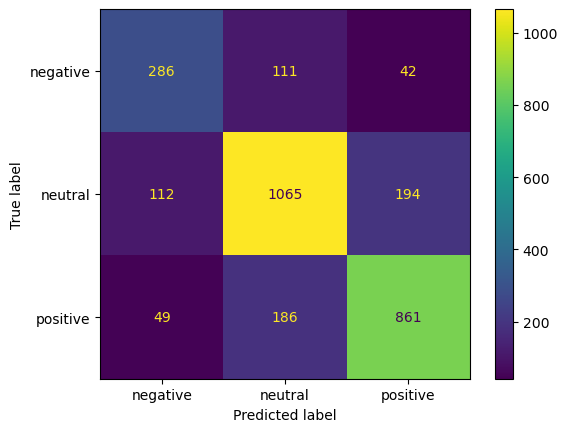

In [19]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(test['sentiment'], predicted_label_text)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_).plot()

### Examine results

Now that we have some predictions, look at some examples of correctly classified and missclassified tweets. First, the correctly classified:

In [20]:
import random

for _sent, _pred, _text in random.sample(list(zip(test['sentiment'], predicted_label_text, train['text'])), 10):
  if _sent == _pred:
    print('LABEL:', _sent)
    print('TWEET:', _text[:100], '...')
    print()

LABEL: positive
TWEET: Thanks to EK\u002c car now smells DELISH!! If you bottled this\u002c it\u2019d be called Saturday Ni ...

LABEL: positive
TWEET: Enjoyed the FLOTUS today in FL! @MichelleObama u r BRILLIANT...simply put! Glad I voted Saturday #Ob ...

LABEL: neutral
TWEET: Heading to Putrajaya\u002c may Allah bless along the way! ...

LABEL: positive
TWEET: Well\u002c it\u2019s Monday again folks :-/ Start of week 4 at OU! But\u002c it\u2019s a new week in ...

LABEL: positive
TWEET: 10 PS4 launch games wed love to see. These are our hopes & dreams Sony\u002c be gentle with them: OP ...

LABEL: negative
TWEET: Just to be sure. Tomorrow is America Day\u002c right? Because I don\u2019t wanna be the redneck in a ...

LABEL: neutral
TWEET: I\u2019m thinking about making August \""Baby Month\"" at Life\u2019s A Celebration. With tips and i ...

LABEL: positive
TWEET: @GuildWars2 C\u2019mon guys fix this please\u002c i dont want this to end up how Diablo III did..... ...

LABEL: positi

And now the missclassified:

In [21]:
for _sent, _pred, _text in random.sample(list(zip(test['sentiment'], predicted_label_text, train['text'])), 20):
  if _sent != _pred:
    print('TRUE LABEL:', _sent)
    print('PREDICTED LABEL:', _pred)
    print('TWEET:', _text[:100], '...')
    print()

TRUE LABEL: positive
PREDICTED LABEL: neutral
TWEET: Hmm Raspberry Pi - Scrap iPads in the class room - have some Pi instead #education @tdsb http://t.co ...

TRUE LABEL: neutral
PREDICTED LABEL: positive
TWEET: Mack sure you check out @carolinakidz1 and @Trilla_Guapo this Saturday @ Club Bodi ...

TRUE LABEL: neutral
PREDICTED LABEL: negative
TWEET: George Zimmerman made his first appearance in public on Friday as he and his wife Shellie have been  ...

TRUE LABEL: positive
PREDICTED LABEL: neutral
TWEET: Stroudsburg vs Pleasant Valley for the MVC title next friday #repeat #MountieNation ...

TRUE LABEL: negative
PREDICTED LABEL: neutral
TWEET: This song says everything about a break up ...Rope To Hang by Neil McSweeney: Dir. Sat Johal of Crow ...

TRUE LABEL: positive
PREDICTED LABEL: neutral
TWEET: AC Milan Ready to Make January Move for Chelsea Full-Back Ashley Cole: San Siro side want Stamford B ...

TRUE LABEL: positive
PREDICTED LABEL: negative
TWEET: RT @imshar0n: @owlcity wow,

## Task 1 - Using a pretrained model

We have now fine-trained our own model, but this is generally not necessary since other people have already fine-tuned models for the same task. This task will take you through the process step by step.

### Task 1a - Sentiment prediction

First we will setup the [selected model](https://huggingface.co/lxyuan/distilbert-base-multilingual-cased-sentiments-student).

In [ ]:
from transformers import pipeline

distilled_student_sentiment_classifier = pipeline(
    model="lxyuan/distilbert-base-multilingual-cased-sentiments-student",
    top_k=None
)

Device set to use cuda:0
c:\Users\Abigail Hayes\miniconda3\envs\llms_hws25\Lib\site-packages\transformers\pipelines\text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


What advantages does this model offer over the model we pretrained ourselves? What are the potential disadvantages?

_Answer here..._

Use this model to predict the sentiment of the two tweets below:

In [35]:
anti_biden_tweet = "Ugh, this was true yesterday and it's also true now: Biden is bad for the country"
pro_biden_tweet = "I'm voting for Biden 100%"


Now create a list with predictions for all of the test dataset.

What is the performance for this model?

## Task 1b - Topic classification

Now we will try a slightly different task. For topic classification, we need a model that has been fine-tuned for this task.

In [29]:
# Load a multi-class classification pipeline - if the model runs on CPU, comment out "device"
classifier = pipeline("text-classification", model="classla/multilingual-IPTC-news-topic-classifier", device=0, max_length=512, truncation=True)

Device set to use cuda:0


Classify these example texts:

In [36]:
texts = [
    "Ugh, this was true yesterday and it's also true now: Biden is bad for the country",
    "It's really scary with the covid numbers increasing so much",
    "Diese Asylanten nehmen weider unsere Arbeitsplätzen",
    "Apoiadores de Bolsonaro ocupam senado federal",
    "Sao Paulo vence Palmeiras em jogo apertado",
    "Лавров та глава МЗС Туреччини обговорили переговори про війну в Україні"
    ]


Now try the same with a sample from our dataset.

In [31]:
data_sample = data.sample(100)
data_sample

,id,sentiment,text
6017,111991323975888899,negative,Well at least my Steelers didn't play tonight
2094,250265462385037312,neutral,Make sure everyone comes out to our first open...
5936,110540813716570112,positive,"@Rastas4Jesus09 Droid Bionic, this Thursday. N..."
6870,102752363693080577,positive,"On September 3 at the Pride Park Ground, Derby..."
346,261556214624837632,neutral,I\u2019m far too stressed about finishing this...
...,...,...,...
6880,100046146361245697,neutral,Have seen 4 deer in Dexter so far tonight @hal...
4606,263506900858060800,positive,STAR wishes all the #students at @BrandeisU a ...
2526,264121431720345600,neutral,Raymond\u2019s been busy and we have homemade ...
6523,100486632314109952,neutral,Woods down to 30th in world rankings: Tiger Wo...
